<a href="https://colab.research.google.com/github/conniepadillav-prog/Machine-Learning-/blob/main/Tarea_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1
Desafío: ¿Podemos afirmar, a partir de estos datos, que últimamente está temblando más?
- Algunas ideas de exploración: magnitud y profundidad; diferencias regionales; evolución
temporal; concentración espacial
- Datos: en aula, archivo earthquakes.csv, para información del catálogo consultar
documentación de USGS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")

##Pregunta de Investigación
¿El aumento en la cantidad de sismos registrados por USGS?

##Comprensión de la muestra

In [ ]:
terremotos = pd.read_csv("/content/earthquakes_usgs.csv")
terremotos.head()

,Unnamed: 0,time,latitude,longitude,depth,mag,magType,place,type,status,net,nst,rms
0,0,1900-01-05T19:00:00.000Z,-3.0,102.0,NaN,7.0,ms,"Southern Sumatra, Indonesia",earthquake,reviewed,cent,NaN,NaN
1,1,1900-01-11T09:07:00.000Z,-5.0,148.0,NaN,7.0,ms,Bismarck Sea,earthquake,reviewed,cent,NaN,NaN
2,2,1900-01-20T06:33:00.000Z,20.0,-105.0,NaN,7.3,mw,"Jalisco, Mexico",earthquake,reviewed,cent,NaN,NaN
3,3,1900-01-31T19:22:00.000Z,48.0,146.0,450.0,7.5,mj,Sea of Okhotsk,earthquake,reviewed,cent,NaN,NaN
4,4,1900-04-30T22:41:14.000Z,36.9,-121.6,NaN,4.5,ml,"Near Aromas, California",earthquake,reviewed,ushis,NaN,NaN


Las principales características disponibles son:

- `time`: Hora del sismo
- `latitude`/ `longitude`: Ubicación en coordenadas
- `depth`: Profundidad
- `mag`: Magnitud del sismo
- `magType`: Tipo de magnitud
- `place`: Lugar
- `type`: Tipo
- `status`: Estado
- `net`:
- `nst`:
- `rms`:

##Tipo de evento

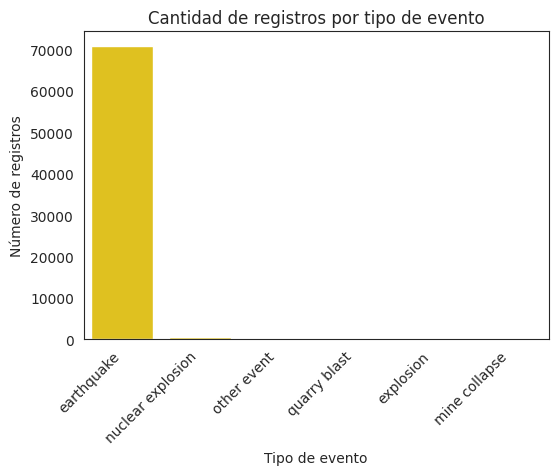

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=terremotos, x="type", color="gold")

plt.xlabel("Tipo de evento")
plt.ylabel("Número de registros")
plt.title("Cantidad de registros por tipo de evento")
plt.xticks(rotation=45, ha='right')

plt.show()

In [ ]:
conteo_tipos = terremotos["type"].value_counts()
print(conteo_tipos)

type
earthquake           70793
nuclear explosion      501
explosion               14
mine collapse            4
quarry blast             1
other event              1
Name: count, dtype: int64


A partir de lo datos, se puede observar que no todos los eventos son por sismos propiamente tal. La cantidad de eventos por otros motivos es considerablemente menos a los sismos naturales. Sin embargo, para efectos de este analisis tomaremos en cuenta solo los datos de terremotos producidos por sismos naturales y se realizara una breve exploración por los otros tipos.

In [ ]:
# Filtramos solo sismos reales, según lo que vimos en el countplot anterior
terremotos_sismos = terremotos[terremotos["type"] == "earthquake"].copy()

# Preparamos la columna de año
terremotos_sismos["time"] = pd.to_datetime(terremotos_sismos["time"])
terremotos_sismos["year"] = terremotos_sismos["time"].dt.year

/tmp/ipykernel_842/1697335855.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  terremotos_sismos["time"] = pd.to_datetime(terremotos_sismos["time"])


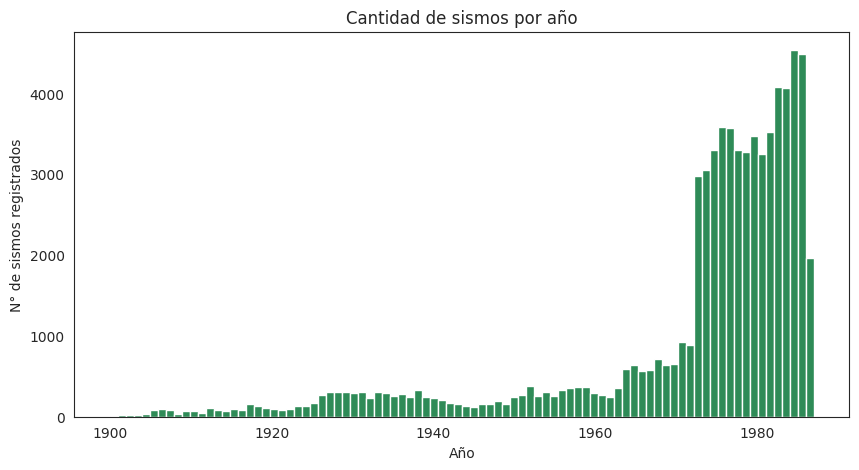

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(terremotos_sismos["year"], bins=terremotos_sismos["year"].nunique(), color="seagreen")
plt.xlabel("Año")
plt.ylabel("N° de sismos registrados")
plt.title("Cantidad de sismos por año")
plt.show()

En términos de cantidad de sismos a simple vista se observa que  la cantidad de sismos detectados aumenta considerablemente con el avance de los años. Esto podría deberse al avance de la tecnología de detección y rigurosidad en el registro de los eventos.

In [ ]:
# Filtramos solo sismos reales, según lo que vimos en el countplot anterior
terremotos_nuclear = terremotos[terremotos["type"] == "nuclear explosion"].copy()

# Preparamos la columna de año
terremotos_nuclear["time"] = pd.to_datetime(terremotos_nuclear["time"])
terremotos_nuclear["year"] = terremotos_nuclear["time"].dt.year

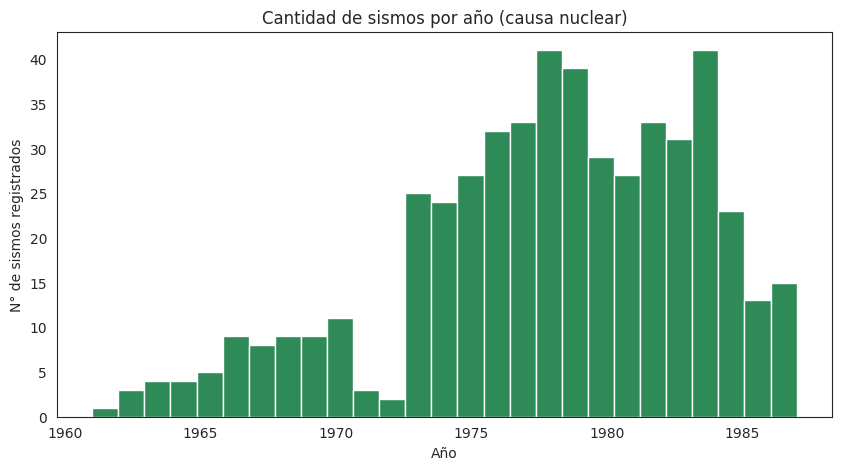

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(terremotos_nuclear["year"], bins=terremotos_nuclear["year"].nunique(), color="seagreen")
plt.xlabel("Año")
plt.ylabel("N° de sismos registrados")
plt.title("Cantidad de sismos por año (causa nuclear)")
plt.show()

##Magnitud

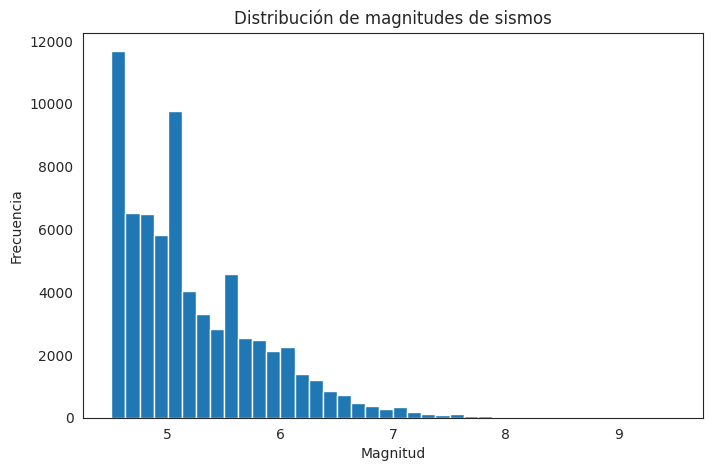

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(terremotos_sismos['mag'].dropna(), bins=40)
plt.xlabel('Magnitud')
plt.ylabel('Frecuencia')
plt.title('Distribución de magnitudes de sismos')
plt.show()

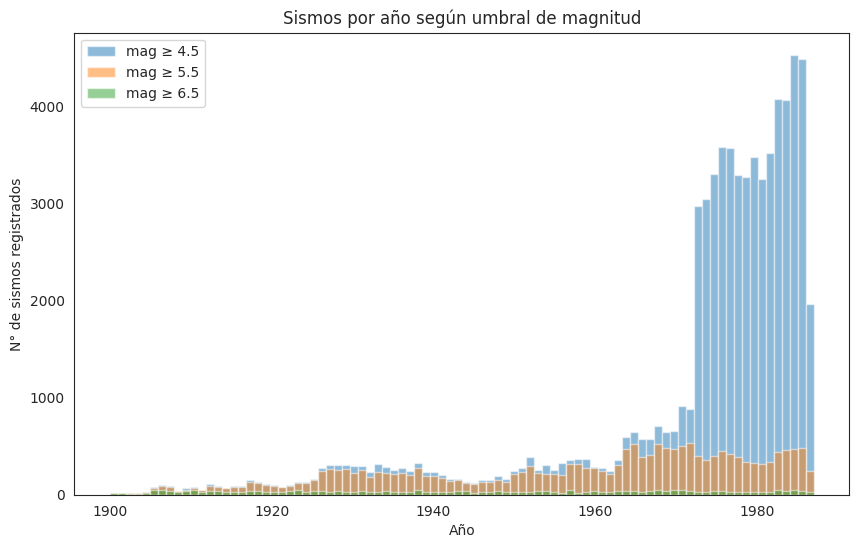

In [ ]:
umbrales = [4.5, 5.5, 6.5]

plt.figure(figsize=(10,6))
for u in umbrales:
    subset = terremotos_sismos[terremotos_sismos["mag"] >= u]
    plt.hist(subset["year"], bins=subset["year"].nunique(),
             alpha=0.5, label=f"mag ≥ {u}")

plt.xlabel("Año")
plt.ylabel("N° de sismos registrados")
plt.title("Sismos por año según umbral de magnitud")
plt.legend()
plt.show()

In [ ]:
Magnitudes = terremotos_sismos["mag"].value_counts()
print(Magnitudes)

mag
4.70    6423
4.80    6389
4.60    5972
4.90    5775
4.50    5562
        ... 
9.50       1
9.20       1
8.70       1
7.62       1
7.72       1
Name: count, Length: 361, dtype: int64


In [ ]:
Tipo_Magnitudes = terremotos_sismos["magType"].value_counts()
print(Tipo_Magnitudes)

magType
mb       46335
mw       19558
ms        3125
ml        1330
md         129
mh          79
uk          65
mB          59
fa          36
mfa         34
mint        13
lg          10
Mw           7
mj           4
mwc          2
m            2
ma           2
mc           1
mb_lg        1
Name: count, dtype: int64


In [ ]:
# Porcentaje de cada magType sobre el total de sismos
porcentajes_magtype = terremotos_sismos["magType"].value_counts(normalize=True) * 100
print(porcentajes_magtype.round(2))

# Porcentaje combinado de los 3 principales (mb, mw, mwc)
top3 = ["mb", "mw", "mwc"]
porcentaje_top3 = porcentajes_magtype[top3].sum()
print(f"\nPorcentaje combinado de mb + mw + mwc: {porcentaje_top3:.2f}%")

magType
mb       65.45
mw       27.63
ms        4.41
ml        1.88
md        0.18
mh        0.11
uk        0.09
mB        0.08
fa        0.05
mfa       0.05
mint      0.02
lg        0.01
Mw        0.01
mj        0.01
mwc       0.00
m         0.00
ma        0.00
mc        0.00
mb_lg     0.00
Name: proportion, dtype: float64

Porcentaje combinado de mb + mw + mwc: 93.08%


Podríamos decir que la mayoria de sismos registrados son de menor magnitud (menores a 5.5) y que la cantidad de registros disminuye a medida que aumenta la magnitud del sismo. Es importante tener en cuenta que se utilizan distintos tipos de magnitud,las cuales no necesariamente son comparables, por lo que es importante discernir la diferencia entre ellas.

Además, se observa que cerca del año 1970 la cantidad de registros de sismos de magnitud baja (entre 4.5 y 5.5) aumenta de forma mucho más notoria que los de magnitudes mayores. Esto puede deberse a una mejora sustancial en la sensibilidad de los equipos de medición, que cada vez pueden registrar con mayor precisión eventos de magnitud baja.



Para efectos del análisis, tomaremos en cuenta las 3 tipos de magnitud más utilizados (93% de los datos).

- **mb (magnitud de ondas de cuerpo, *body wave*)**:  Se calcula a partir de la amplitud de las primeras ondas P que llegan a la estación sismológica. Es confiable para sismos de magnitud media (~4.0 a 6.5), pero se satura sobre M6.5, es decir, deja de reflejar bien el verdadero tamaño de sismos muy grandes.

- **mw (magnitud de momento, *moment magnitude*)**: Se basa en el momento sísmico, una medida física derivada de la energía liberada por la ruptura de la falla. A diferencia de mb, no se satura, por lo que es la escala más precisa para sismos grandes. Es la magnitud "de referencia" moderna usada por USGS.

- **mwc (magnitud de momento centroide)**: Una variante de mw derivada de la inversión de ondas superficiales de largo período. Se usa principalmente cuando la variante *mww* no está disponible, típicamente en sismos de M5.5 o mayores.



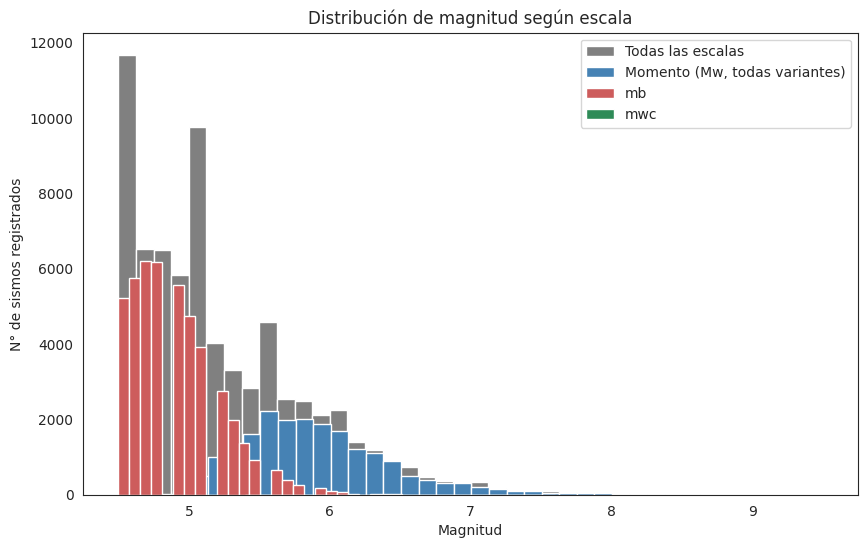

In [ ]:
solo_momento = terremotos_sismos[terremotos_sismos["magType"].isin(["mw", "mwc", "mwb", "mww"])]
solo_mb = terremotos_sismos[terremotos_sismos["magType"] == "mb"]
solo_mwc = terremotos_sismos[terremotos_sismos["magType"] == "mwc"]

plt.figure(figsize=(10,6))

for datos, nombre, color in [
    (terremotos_sismos["mag"].dropna(), "Todas las escalas", "gray"),
    (solo_momento["mag"].dropna(), "Momento (Mw, todas variantes)", "steelblue"),
    (solo_mb["mag"].dropna(), "mb", "indianred"),
    (solo_mwc["mag"].dropna(), "mwc", "seagreen"),
]:
    plt.hist(datos, bins=40, label=nombre, color=color)

plt.xlabel("Magnitud")
plt.ylabel("N° de sismos registrados")
plt.title("Distribución de magnitud según escala")
plt.legend()
plt.show()

###Sismos por profundidad

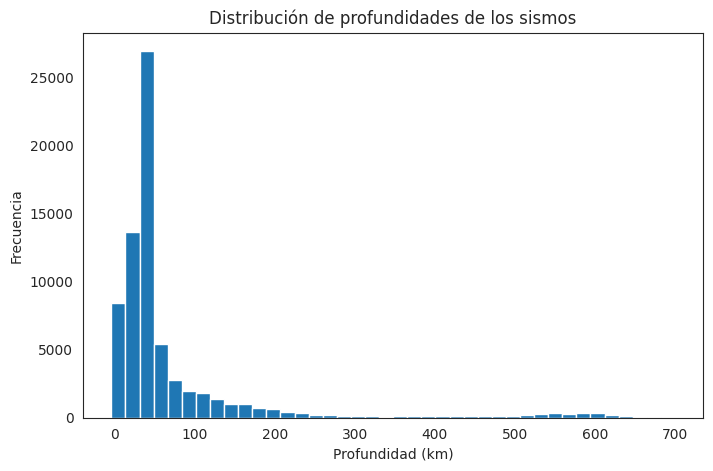

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(terremotos['depth'].dropna(), bins=40)
plt.xlabel('Profundidad (km)')
plt.ylabel('Frecuencia')
plt.title('Distribución de profundidades de los sismos')
plt.show()

###Cantidad de sismos por año

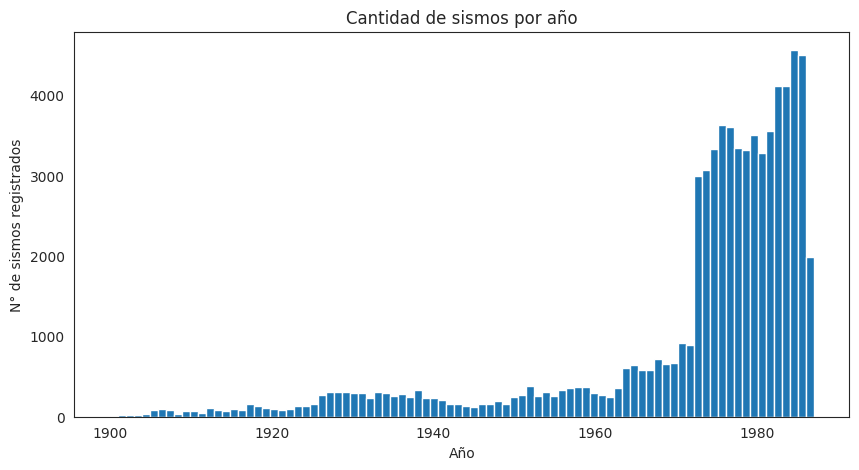

In [ ]:
terremotos['time'] = pd.to_datetime(terremotos['time'], format='mixed', utc=True)
terremotos['year'] = terremotos['time'].dt.year

plt.figure(figsize=(10,5))
plt.hist(terremotos['year'], bins=terremotos['year'].nunique())
plt.xlabel('Año')
plt.ylabel('N° de sismos registrados')
plt.title('Cantidad de sismos por año')
plt.show()

Observamos que hay un aumento considerable de registros posterior a los años 60, lo cual no necesariamente se debe a que la tierra empezó a temblar más, sino a un salto en la capacidad de detección de los sismos y rigurosidad en el registro que coinciden con estas fechas:
- Se desplegó la WWSSN (World-Wide Standardized Seismograph Network) en los años 60, una red de ~120 estaciones sismográficas estandarizadas instaladas en todo el mundo. No es sorprendente que el número de "grandes terremotos" detectados globalmente haya aumentado significativamente poco después de que la red comenzara a operar. Curiosamente, esa red se financió originalmente para detectar pruebas nucleares subterráneas, no para sismología pura, pero terminó siendo la base de toda la sismología moderna.
(The American Prospect)
- Digitalización en los 70: durante los años 70 algunas estaciones de la WWSSN se equiparon con instrumentos digitales y sismómetros de pozo profundo, lo que mejoró mucho la sensibilidad y precisión de detección.
(Science.gov)
- Cobertura geográfica más pareja: antes de la WWSSN, la red se enfocaba en Eurasia y se perdían muchos sismos "importantes" en otras partes del mundo — así que parte del salto es simplemente que antes había zonas ciegas.
(The American Prospect)
-Mejores catálogos internacionales: se creó el ISC (International Seismological Centre) y se estandarizó cómo se reportaban y consolidaban los eventos entre agencias.

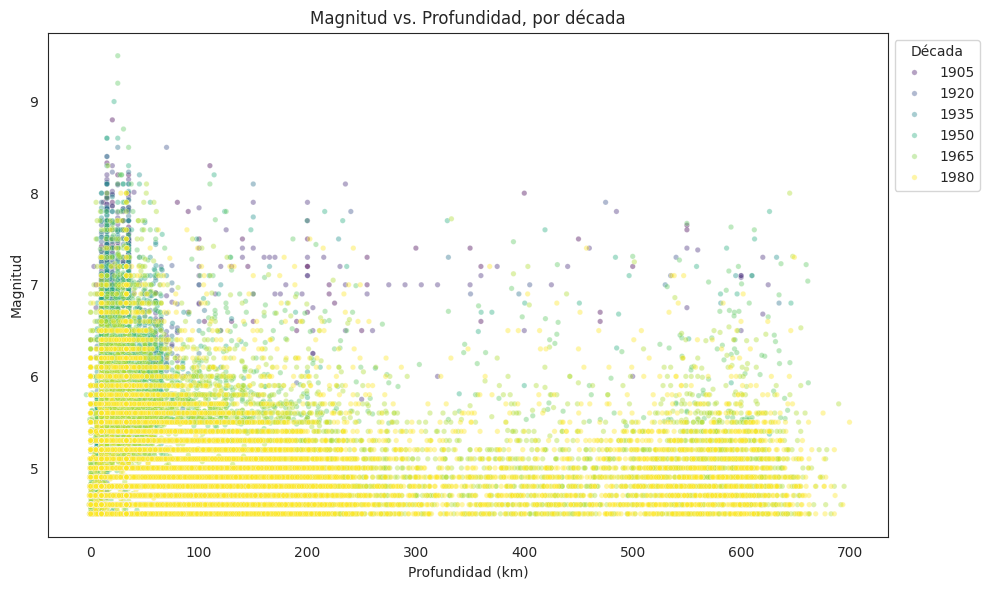

In [ ]:
# Crear columna de década (si no la tienes ya)
terremotos['decada'] = (terremotos['year'] // 10) * 10

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=terremotos.dropna(subset=['mag', 'depth']),
    x='depth', y='mag',
    hue='decada',
    palette='viridis',
    alpha=0.4,
    s=15
)
plt.xlabel('Profundidad (km)')
plt.ylabel('Magnitud')
plt.title('Magnitud vs. Profundidad, por década')
plt.legend(title='Década', bbox_to_anchor=(1.0, 1), loc='upper left')
plt.tight_layout()
plt.show()

En el gráfico "Magnitud vs. profundida, por decada" se observa nuevamente que la cantidad de sismos registrados en la decada de los 80 supera con creces a los registros de cualquier otra decada. Además se observa muy claramente que desde la decada de 1970 se empiezan a registrar muchos fenómenos de baja magnitud y alta profundidad, es decir, sismos complejos de detectar. Asimismo, queda patente que a principios del siglo XX, solo se lograba registrar sismos de alta magnitud y poca profundidad, que probablemente corresponden a terremotos registrados con impacto en infraestructura o vidas humanas.

Con todo esto en consideración, otro aspecto interesante de analizar es la ubicación de los sismos registrados, visualizados por año. Según lo que se viene argumentando hasta acá, debiese notarse que la instalación de estaciones en zonas lejanas a europa-asia permite registrar eventos que antes pasaban desapercibidos.

In [ ]:
import plotly.express as px

datos = terremotos.dropna(subset=['latitude', 'longitude', 'year'])
datos = datos.sort_values('year', ascending=False)  # los más antiguos quedan al final -> se dibujan encima

fig = px.scatter_geo(
    datos,
    lat='latitude',
    lon='longitude',
    color='year',
    color_continuous_scale='Viridis',
    opacity=0.3,
    title='Distribución global de sismos registrados, coloreado por año',
    projection='natural earth'
)

fig.update_traces(marker=dict(size=3))
fig.update_layout(height=600)
fig.show()

En el gráfico mapa, se observa claramente que zonas como Europa (principalmente cerca de la península balcánica), la costa pacífica de Asia y la costa pacífica de américa del norte son prácticamente las únicas zonas del planeta que presentan registros consistentes desde principios del siglo XX. Por su parte, zonas como america del sur, el pacífico sur, el oceano índico, oceano atlántico y africa, solo empiezan a acumular registros desde la decada de 1970. Esto respalda la idea de que la apertura de nuevas estaciones y la sistematización de las técnicas de registro sea lo que produce el aumento significativo de sismos registrados hacia finales del siglo XX.

La pregunta lógica que hacerse a continuación sería: ¿Qué pasa si solo consideramos sismos de alta magnitud? Si el aumento en la cantidad de sismos que se observa desde 1970 realmente se debe a la mejora en la capacidad de detectar sismos de baja magnitud, los eventos de alta magnitud debiesen mantenerse mas o menos estables a lo largo del tiempo. Con esto ya se podría responder directamente la pregunta: **¿Está temblando más ultimamente?**
Para visualizar esto, se consideraran sismos de magnitud superior a 6, de tal manera que la profundidad no tenga mucho peso (puede pasar que un movimiento de alta magnitud, pero que se orgina muy profundo, también sea difícil de detectar con instrumentos muy antiguos).

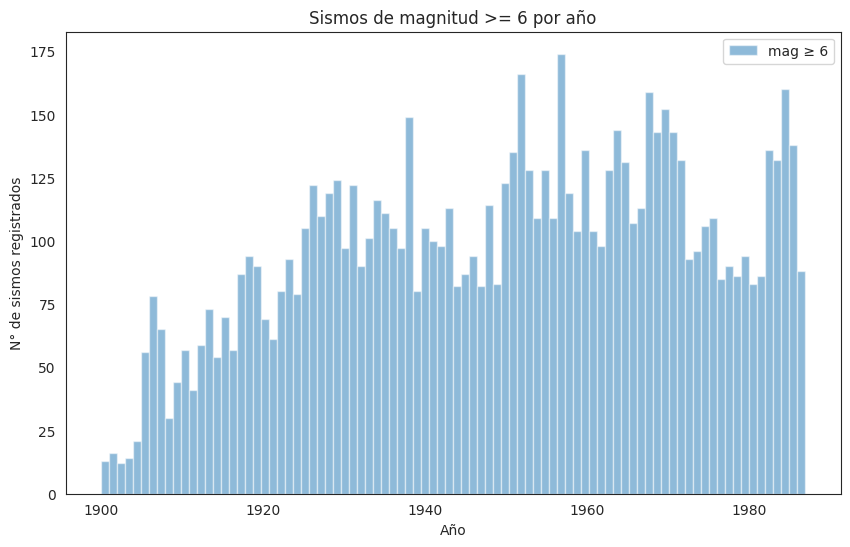

In [ ]:
plt.figure(figsize=(10,6))

subset = terremotos_sismos[terremotos_sismos["mag"] >= 6]
plt.hist(subset["year"], bins=subset["year"].nunique(),
             alpha=0.5, label=f"mag ≥ 6")

plt.xlabel("Año")
plt.ylabel("N° de sismos registrados")
plt.title("Sismos de magnitud >= 6 por año")
plt.legend()
plt.show()


Al mirar los registros de sismos de altas magnitudes, se observa un comportamiento mucho más estable. Sin embargo, igual se percibe un aumento de registros con el tiempo, que si bien se va suavizando con los años, no se puede descartar.

A continuación, se hará una evaluación de la desviación estándar del número de registros dividiendolos por magnitud en los siguientes segmentos:

- 0-4.5
- 4.5-5.5
- 5.5-6.5
- 6.5-7.5
- 7.5-9.0

In [ ]:
# Asegurarnos de que time sea datetime
terremotos_sismos["time"] = pd.to_datetime(terremotos_sismos["time"])

# Extraer el año
terremotos_sismos["year"] = terremotos_sismos["time"].dt.year

# Umbrales de magnitud
umbrales = [0, 4.5, 5.5, 6.5, 7.5]

resultados_std = {}

for u in umbrales:

    # Seleccionar sismos sobre el umbral
    datos = terremotos_sismos[terremotos_sismos["mag"] >= u]

    # Número de sismos por año
    sismos_por_año = datos.groupby("year").size()

    # Desviación estándar
    std = sismos_por_año.std()

    resultados_std[u] = std

# Mostrar resultados
for u, std in resultados_std.items():
    print(f"M ≥ {u}: desviación estándar = {std:.2f}")


M ≥ 0: desviación estándar = 1267.54
M ≥ 4.5: desviación estándar = 1267.54
M ≥ 5.5: desviación estándar = 144.10
M ≥ 6.5: desviación estándar = 9.12
M ≥ 7.5: desviación estándar = 2.09


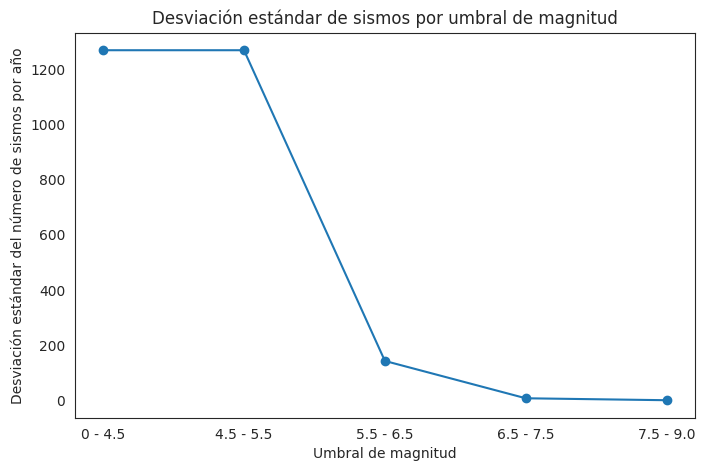

In [ ]:
plt.figure(figsize=(8, 5))

umb = ['0 - 4.5','4.5 - 5.5','5.5 - 6.5','6.5 - 7.5','7.5 - 9.0']

plt.plot([str(u) for u in umb], resultados_std.values(), 'o-')
plt.xlabel("Umbral de magnitud")
plt.ylabel("Desviación estándar del número de sismos por año")
plt.title("Desviación estándar de sismos por umbral de magnitud")

plt.show()

Como se observa, la desviación estándar es altísima para sismos de baja magnitud. Esto tiene sentido considerando que apenas en la decada de 1970 empieza a haber un volumen considerable de registros de estas magnitudes. No obstante, superando el umbral de los 5.5 de magnitud, la desviación estándar disminuye abruptamente, llegando a ser, para sismos de 6.5 - 7.5 de magntitud un 0,65% de la desviación para sismos de magnitudes 4.5 - 5.5 (9.77 frente a 1459.59).
Para sismos de magnitud mayor a 7.5, la desviación estándar es mínima: 2.03. Es decir, la diferencia promedio de registros año a año es app. 2 eventos.

Con todo esto en consideración, se puede sostener que la cantidad de eventos correspondientes a sismos de magnitudes altas (cuya detección es mucho menos dependiente de la sensibilidad de los instrumentos disponibles que para bajas magnitudes) no varía significativamente en la ventana de tiempo que abarcan los datos.

# Conlusión

A partir del análisis de los datos de USGS, se observa un aumento en la cantidad de sismos registrados durante los últimos años, especialmente para magnitudes menores. Sin embargo, este incremento no permite afirmar que actualmente ocurran más sismos que en el pasado, ya que también puede estar relacionado con la mejora en los sistemas de detección y el aumento de estaciones de monitoreo. Se constató además que a principios del siglo XX existía una brecha greográfica en términos de la capacidad de registro, que se fue disipando durante la segunda mitad del siglo XX, simultaneo al aumento en la capacidad de detección de eventos de menor magnitud (esto se evidenció además al observar un aumento claro en la capacidad de detectar sismos originados cada vez a mayores profundidades).

Al considerar umbrales de magnitud mayores, la variabilidad temporal es menor, lo que sugiere que el aumento observado está fuertemente influenciado por la capacidad de registro. Por lo tanto, **con estos datos no podemos concluir que últimamente esté temblando más; sí podemos afirmar que actualmente se registran más sismos**.
